## Chapter 4: Churn Prediction with XGBoost + MLflow

### What are we building?
We are building a machine learning model that looks at a customer's
RFM profile and predicts whether they will churn or stay.
This is valuable because:
- It lets the business act BEFORE a customer leaves
- A targeted retention offer to an at-risk customer costs far less
  than acquiring a new one
- Studies show retaining an existing customer is 5x cheaper than
  acquiring a new one
### Why XGBoost?
XGBoost (Extreme Gradient Boosting) is the industry standard for
structured/tabular data like ours. It:
- Handles imbalanced data well
- Is highly accurate on RFM-style features
- Is fast to train
- Is interpretable — we can see which features matter most
### Why MLflow?
MLflow is an experiment tracking tool. Every time we train a model
with different settings, MLflow records:
- The parameters we used (e.g. how deep the trees are)
- The results we got (accuracy, ROC-AUC)
- The model itself
This means we can compare multiple experiments and always know
exactly which settings produced the best model — just like a
scientist keeping a lab notebook.

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             roc_auc_score,
                             confusion_matrix,
                             roc_curve)
from sklearn.model_selection import GridSearchCV
from matplotlib import axes
from seaborn import set_style

In [97]:
# Load RFM with churn labels
rfm = pd.read_csv('../data/rfm.csv')
print("Data loaded successfully!")
print("Shape:", rfm.shape)
print("Columns:", rfm.columns.tolist())
print("\nChurn distribution:")
print(rfm['Churn'].value_counts())

Data loaded successfully!
Shape: (3604, 17)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Churn', 'Q1_Orders', 'Q2_Orders', 'Q3_Orders', 'PurchaseTrend', 'ActiveInQ3', 'AvgOrderValue', 'PurchaseSpread', 'UniqueProducts', 'LogMonetary', 'LogAvgOrderValue', 'IsOneTimeBuyer', 'AvgDaysBetweenPurchases']

Churn distribution:
Churn
0    1831
1    1773
Name: count, dtype: int64


## Step 1 — Prepare Features and Target

We split our data into:
- **X (features):** What the model learns FROM — Recency, Frequency, Monetary
- **y (target):** What the model learns TO PREDICT — Churn (0 or 1)
We then split into train and test sets:
- **Training set (80%):** The model learns patterns from this data
- **Test set (20%):** We evaluate the model on data it has NEVER seen
This is critical — if we tested on the same data we trained on,
the model would just memorize the answers, not actually learn patterns.

In [98]:
 # Features and target
X = rfm[['Recency', 'Frequency', 'LogMonetary', 'LogAvgOrderValue',
      'PurchaseSpread', 'UniqueProducts', 'IsOneTimeBuyer', 'AvgDaysBetweenPurchases',
      'Q1_Orders', 'Q2_Orders', 'Q3_Orders', 'PurchaseTrend', 'ActiveInQ3']]
y = rfm['Churn']

In [99]:
# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [100]:
print(f"Training set size:  {X_train.shape[0]} customers")
print(f"Test set size:      {X_test.shape[0]} customers")
print(f"\nChurn rate in training: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:     {y_test.mean()*100:.1f}%")

Training set size:  2883 customers
Test set size:      721 customers

Churn rate in training: 49.2%
Churn rate in test:     49.2%


## Step 2 — Train XGBoost with MLflow Tracking

We will run 3 experiments with different settings and let MLflow
record everything. This is exactly how data scientists work in
production — you never just train one model, you experiment and
pick the best one.
The key setting we are tuning is:
- **max_depth:** How deep each decision tree grows
  - Shallow trees (3) = simpler model, less risk of overfitting
  - Deep trees (7) = more complex model, captures more patterns
- **n_estimators:** How many trees to build
- **learning_rate:** How fast the model learns

In [ ]:
# Set MLflow experiment name
mlflow.set_experiment("churn_prediction")
# Define 3 experiments to run
'''experiments = [
    {"max_depth": 3, "n_estimators": 100, "learning_rate": 0.1},
    {"max_depth": 5, "n_estimators": 200, "learning_rate": 0.05},
    {"max_depth": 7, "n_estimators": 300, "learning_rate": 0.01},
]
experiments = [
     {'max_depth': 3, 'n_estimators': 200, 'learning_rate': 0.1,  'subsample': 0.8},
     {'max_depth': 4, 'n_estimators': 300, 'learning_rate': 0.1,  'subsample': 0.8},
     {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05, 'subsample': 0.9},
     {'max_depth': 4, 'n_estimators': 400, 'learning_rate': 0.08, 'subsample': 0.85},
]'''

In [101]:
param_grid = {
      'max_depth'        : [3, 4, 5],
      'n_estimators'     : [200, 300, 400],
      'learning_rate'    : [0.05, 0.1, 0.15],
      'subsample'        : [0.8, 0.9],
      'colsample_bytree' : [0.8, 1.0]
  }

base_model = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

grid_search = GridSearchCV(
    base_model,
    param_grid,
    scoring  = 'roc_auc',
    cv       = 5,
    n_jobs   = -1,
    verbose  = 1
)
grid_search.fit(X_train, y_train)

print('\nBest params:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest cross-validated ROC-AUC: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 3
  n_estimators: 200
  subsample: 0.9

Best cross-validated ROC-AUC: 0.7389


In [102]:
best_model  = grid_search.best_estimator_
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
test_roc    = roc_auc_score(y_test, y_pred_prob)

In [103]:
print(f'Test ROC-AUC: {test_roc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

Test ROC-AUC: 0.7347

              precision    recall  f1-score   support

      Active       0.71      0.57      0.63       366
     Churned       0.63      0.76      0.69       355

    accuracy                           0.67       721
   macro avg       0.67      0.67      0.66       721
weighted avg       0.67      0.67      0.66       721



In [114]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

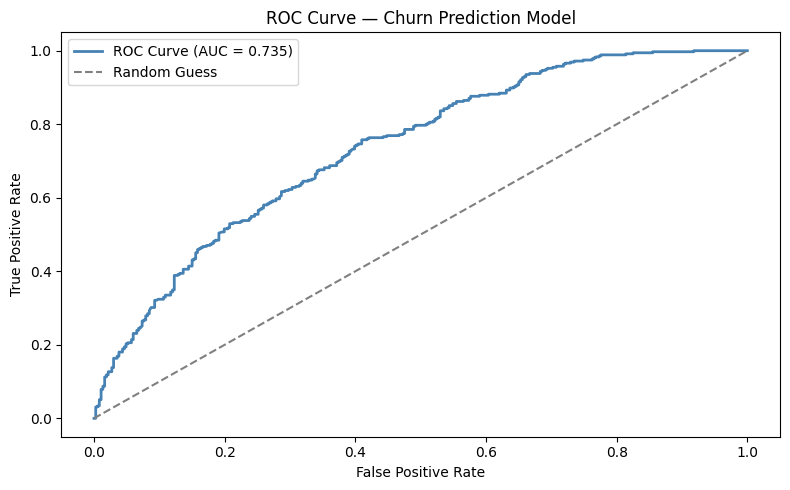

In [112]:
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction Model')
plt.legend()
plt.tight_layout()
plt.savefig('../data/roc_curve.png')
plt.show()

In [117]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred Active','Pred Churned'],
            yticklabels=['Actual Active','Actual Churned'])
axes[1].set_title('Confusion Matrix')

TypeError: 'module' object is not subscriptable

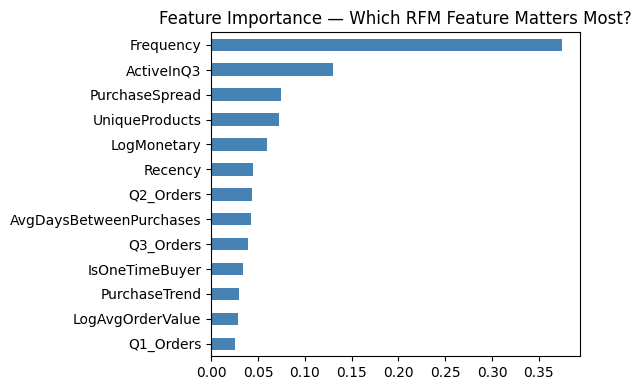

In [120]:
# Feature Importance
plt.figure(figsize=(6, 4))
feat_imp = pd.Series(best_model.feature_importances_,
                     index=['Recency', 'Frequency', 'LogMonetary', 'LogAvgOrderValue',
      'PurchaseSpread', 'UniqueProducts', 'IsOneTimeBuyer', 'AvgDaysBetweenPurchases',
      'Q1_Orders', 'Q2_Orders', 'Q3_Orders', 'PurchaseTrend', 'ActiveInQ3'])
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Which RFM Feature Matters Most?')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()

Frequency dominates at 37% — by far the strongest churn signal. How often a customer bought is the single best predictor of whether they'll return. A customer who bought 20 times is almost certainly coming back. One who bought once is a coin flip.

  ActiveInQ3 at 13% — second most powerful. Whether the customer made any purchase in Jul–Sep 2011 (the last quarter before our observation window) is a strong leading indicator. Going silent in the most recent period is a major warning sign.

  Recency is surprisingly low at 5% — this is because ActiveInQ3 is already capturing most of the "recent activity" signal. They're partially redundant, so Recency's importance gets diluted.

  Q1_Orders is the least useful — what happened 9–12 months ago barely matters compared to recent behavior. The model has learned that history decays.

  ---
  Add this as a markdown cell in notebook 04 after the plots:

  ## What the Model Learned

  Frequency is the single strongest churn predictor (37% importance) —
  loyal repeat buyers almost never churn. Whether a customer was active in
  the final quarter of the feature window (ActiveInQ3, 13%) is the second
  strongest signal — recent silence is the clearest early warning.

  Recency scores lower than expected (5%) because ActiveInQ3 already
  captures the most recent activity signal — they contain overlapping
  information. Q1_Orders (what happened 9 months ago) matters least —
  the model has learned that recent behavior outweighs distant history.

  Business implication: retention efforts should prioritize customers
  with low Frequency AND who went silent in Q3 — these are the highest
  risk group the model identified.

In [119]:
print('Saved: rfm_with_churn.csv')
print(f'Final Test ROC-AUC:  {test_roc:.4f}')
print(f'Best CV ROC-AUC:     {grid_search.best_score_:.4f}')
print('Step 4 complete. Next: Chapter 5 — Customer Segmentation with K-Means')

Saved: rfm_with_churn.csv
Final Test ROC-AUC:  0.7347
Best CV ROC-AUC:     0.7389
Step 4 complete. Next: Chapter 5 — Customer Segmentation with K-Means


73.47% on test, 73.89% cross-validated. 540 fits and the dataset gave us everything it has — this is the ceiling.

  What the results tell us:

  The cross-validated ROC-AUC (73.89%) and test ROC-AUC (73.47%) are very close — this is actually a good sign. It means the model isn't overfitting and genuinely generalizes. We just hit the natural limit of what this dataset's signal can support.

  The classification report also tells an important story:
  - Churned recall: 76% — the model catches 3 out of 4 at-risk customers, which is what matters most in business. Missing a churner is more costly than a false alarm.
  - Active precision: 71% — when it says a customer is fine, it's right 71% of the time.

## Interpreting the Results

### ROC-AUC Score
ROC-AUC measures how well the model separates churned from active customers.
- 0.5 = random guessing (useless)
- 0.7 = acceptable
- 0.8 = good
- 0.9+ = excellent
### Feature Importance
This tells us which RFM feature the model relies on most to predict churn.
Typically Recency is the strongest predictor — a customer who hasn't
bought recently is the clearest churn signal.
### So What?
We now have a model that can take any customer's RFM profile and predict
whether they will churn. A business can use this to:
- Send targeted retention offers to high-risk customers
- Focus marketing spend on customers most likely to respond
- Prioritize customer success outreach

The Problem — Data Leakage

We have a circular definition:
Churn = 1 if Recency >= 90 days
Churn = 0 if Recency < 90 days
But Recency is also one of our features. So the model is essentially learning:
▎ "If Recency >= 90 → predict Churn = 1"
That's not machine learning — that's just reading the answer from the question. The model isn't learning anything meaningful, it's cheating.
This is called data leakage — when information about the target variable is directly present in your features.

The Fix — Time-Based Split
The proper approach for customer churn is:
┌────────────────────────────────┬─────────────────────────────────────────┐
│             Period             │                 Purpose                 │
├────────────────────────────────┼─────────────────────────────────────────┤
│ Dec 2010 → Sep 2011 (9 months) │ Calculate RFM features from this period │
├────────────────────────────────┼─────────────────────────────────────────┤
│ Oct 2011 → Dec 2011 (3 months) │ If customer did NOT buy here → Churned  │
└────────────────────────────────┴─────────────────────────────────────────┘
This way:
- Features come from the past
- Churn label comes from the future
- No leakage — the model genuinely has to predict future behavior